# FP32 ResNet18 Baseline (no KD, no quantization)

This model is the **second comparison point** required by Task 4: it isolates the effect of adding KD+ternary-QAT in Stage 3, by using the exact same architecture family and training engine as the student, but full precision and trained with plain supervised cross-entropy (no teacher, no quantization).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
from src.utils import set_seed, get_device, plot_training_curves

set_seed(42)
device = get_device()
print("Using device:", device)


Using device: cuda


In [2]:
from src.data import get_cifar10_loaders

train_loader, val_loader, test_loader = get_cifar10_loaders(
    data_dir="../data", batch_size=128, val_fraction=0.1, num_workers=2, seed=42
)


In [3]:
from src.resnet_cifar import resnet18_cifar
from src.utils import count_parameters

baseline = resnet18_cifar(num_classes=10)
print(f"Total parameters: {count_parameters(baseline):,}")


Total parameters: 11,173,962


## Train
Same training engine (`src/engine.py`) as the teacher, same recipe family, only the architecture differs — this keeps the baseline comparison fair.

In [4]:
from src.config import BaselineConfig
from src.engine import train_supervised

cfg = BaselineConfig()
history, best_val_acc = train_supervised(
    baseline, train_loader, val_loader,
    epochs=cfg.epochs, lr=cfg.lr, momentum=cfg.momentum,
    weight_decay=cfg.weight_decay, device=device,
    label_smoothing=cfg.label_smoothing,
    checkpoint_path=cfg.checkpoint_path,
)
print(f"Best validation accuracy: {best_val_acc:.2f}%")


Epoch   1/160 | train_loss 2.0684 acc 29.16% | val_loss 1.6822 acc 44.50% | lr 0.09999
Epoch   2/160 | train_loss 1.5728 acc 49.82% | val_loss 1.5968 acc 50.88% | lr 0.09996
Epoch   3/160 | train_loss 1.3064 acc 63.75% | val_loss 1.3638 acc 62.60% | lr 0.09991
Epoch   4/160 | train_loss 1.1385 acc 71.91% | val_loss 1.2410 acc 67.18% | lr 0.09985
Epoch   5/160 | train_loss 1.0366 acc 76.62% | val_loss 1.1005 acc 73.82% | lr 0.09976
Epoch   6/160 | train_loss 0.9768 acc 79.41% | val_loss 0.9839 acc 78.58% | lr 0.09965
Epoch   7/160 | train_loss 0.9304 acc 81.19% | val_loss 0.9481 acc 80.48% | lr 0.09953
Epoch   8/160 | train_loss 0.8996 acc 82.65% | val_loss 0.9962 acc 79.16% | lr 0.09938
Epoch   9/160 | train_loss 0.8828 acc 83.49% | val_loss 0.9665 acc 79.94% | lr 0.09922
Epoch  10/160 | train_loss 0.8602 acc 84.56% | val_loss 0.9489 acc 80.82% | lr 0.09904
Epoch  11/160 | train_loss 0.8477 acc 85.12% | val_loss 0.9563 acc 80.36% | lr 0.09884
Epoch  12/160 | train_loss 0.8347 acc 85.61

Epoch  96/160 | train_loss 0.6009 acc 95.81% | val_loss 0.7665 acc 89.14% | lr 0.03455
Epoch  97/160 | train_loss 0.5951 acc 96.16% | val_loss 0.7117 acc 91.06% | lr 0.03362
Epoch  98/160 | train_loss 0.5931 acc 96.13% | val_loss 0.7129 acc 91.26% | lr 0.03269
Epoch  99/160 | train_loss 0.5929 acc 96.05% | val_loss 0.7430 acc 90.28% | lr 0.03178
Epoch 100/160 | train_loss 0.5874 acc 96.41% | val_loss 0.7248 acc 90.66% | lr 0.03087
Epoch 101/160 | train_loss 0.5847 acc 96.48% | val_loss 0.7069 acc 90.92% | lr 0.02996
Epoch 102/160 | train_loss 0.5841 acc 96.52% | val_loss 0.7251 acc 90.92% | lr 0.02907
Epoch 103/160 | train_loss 0.5734 acc 97.08% | val_loss 0.7043 acc 91.64% | lr 0.02818
Epoch 104/160 | train_loss 0.5782 acc 96.83% | val_loss 0.7323 acc 90.72% | lr 0.02730
Epoch 105/160 | train_loss 0.5731 acc 96.91% | val_loss 0.7006 acc 91.54% | lr 0.02643
Epoch 106/160 | train_loss 0.5723 acc 97.03% | val_loss 0.7192 acc 90.58% | lr 0.02557
Epoch 107/160 | train_loss 0.5671 acc 97.27

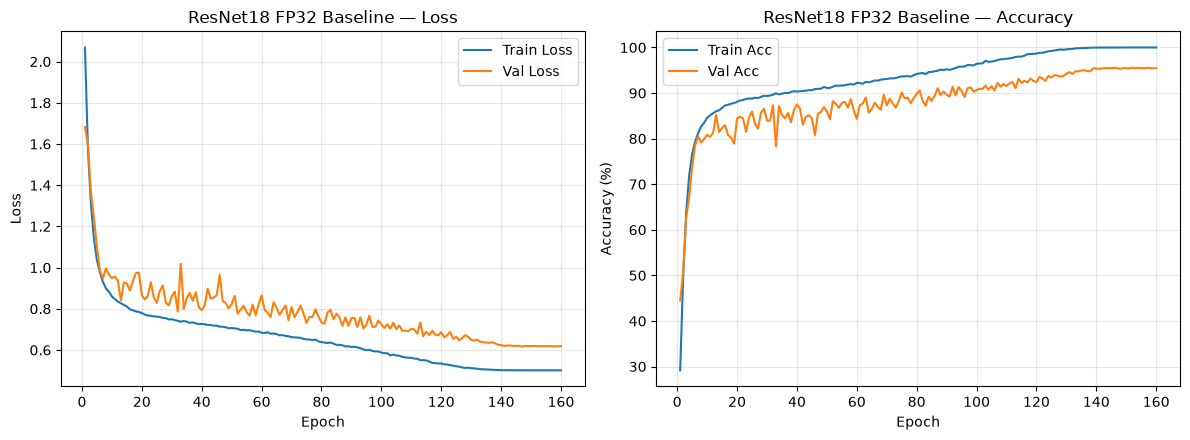

In [5]:
plot_training_curves(history, title="ResNet18 FP32 Baseline", save_path=cfg.curve_plot_path)


In [6]:
from src.evaluate import evaluate_accuracy
from src.data import get_train_eval_loader

ckpt = torch.load(cfg.checkpoint_path, map_location=device)
baseline.load_state_dict(ckpt["model_state_dict"])
baseline.to(device)

train_eval_loader = get_train_eval_loader(data_dir="../data", batch_size=256)
train_acc = evaluate_accuracy(baseline, train_eval_loader, device)
test_acc = evaluate_accuracy(baseline, test_loader, device)

print(f"Train accuracy: {train_acc:.2f}%")
print(f"Test accuracy:  {test_acc:.2f}%")
print(f"Train-test gap: {train_acc - test_acc:.2f} pp")

Train accuracy: 99.56%
Test accuracy:  95.08%
Train-test gap: 4.48 pp
